In [1]:

import pandas as pd
import numpy as np
import os
import openpyxl
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

# Load data

In [2]:
input_dir = "/mnt/c/users/helen/Desktop/FIBERS"

In [3]:
dfs = []

for root, dirs, files in os.walk(input_dir):
    for filename in files:
        if filename.lower().endswith(".csv"):

            path = os.path.join(root, filename)

            df = pd.read_csv(path)

            # Optional metadata
            df["File"] = os.path.splitext(filename)[0].replace(" ", "_")
            df["Path"] = path

            dfs.append(df) 

# Combine all tables
data = pd.concat(dfs, ignore_index=True)

# Create ROI column
data['ROI'] = data['Label'].apply(lambda x: x.split(":")[1])
data['Sample_name'] = data['File'].apply(lambda x: x.split("_")[1].split("-")[0])

# Delete first 3 columns
data.drop(data.columns[[0, 1, 2]], axis=1, inplace=True)

# Reorder columns
data = data[
    [
        "Sample_name",
        "File",
        "Measurement_type",
        "Length",
        "ROI",
        "Path"
    ]
]

In [ ]:
# Fix Sample name manually for some dataframe
data["Sample_name"] = data["Sample_name"].apply(
    lambda x: "WT" if "1h15min" in x else x
)

In [16]:
# Split data into 2 dataframes
speed = data[data['Measurement_type']=='Fiber_length']
iod = data[data['Measurement_type']=='Interorigin_distance']

In [20]:
speed

,Sample_name,File,Measurement_type,Length,ROI,Path
0,MGS1,siORC1_MGS1-02_Fiber_length,Fiber_length,51.108,0303-0404,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
1,MGS1,siORC1_MGS1-02_Fiber_length,Fiber_length,37.202,0273-0360,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
2,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,55.027,0944-0253,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
3,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,68.244,0968-0321,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
4,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,100.000,0581-0161,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
...,...,...,...,...,...,...
749,WT,HCl_1h15min_15o_2_-05_Fiber_length,Fiber_length,55.317,0717-0655,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
750,WT,HCl_1h15min_15o_2_-06_Fiber_length,Fiber_length,44.204,0280-0172,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
751,WT,HCl_1h15min_15o_2_-06_Fiber_length,Fiber_length,40.497,0307-0131,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
752,WT,HCl_1h15min_15o_2_-06_Fiber_length,Fiber_length,33.015,0281-0420,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...


# Process replication speed

In [11]:
conversion_factor = 2.59 # kb/µm
time = 20 # minutes

In [18]:
# Checking speed file
counts = speed.groupby("File").size()
odd_files = counts[counts % 2 != 0].index.tolist()

if len(odd_files) == 0:
    print("All files contain an even number of fibers.")
else:
    print("The following files contain an odd number of fibers will be removed:")
    print(*odd_files, sep="\n")
    
    # Removing odd files from speed dataframe
    speed = speed[~speed["File"].isin(odd_files)].copy()

The following files contain an odd number of fibers will be removed:
siORC1_MGS2-03_Fiber_length
siORC1_MGS4_Fiber_length


In [42]:
# Add extra inedex to group pairs of files
speed["Index"] = speed.groupby("File").cumcount() // 2

# Calculate sum of fiber length in pairs
speed_processed = speed.groupby(["File", "Index"], as_index=False).agg(
        Total_Length=("Length", "sum"),
        ROI=("ROI", list),
        Path=("Path", "first"),
        Sample_name=("Sample_name", "first")
        )

# Convert speed to kb/min
speed_processed['Speed_kb_min'] = speed_processed['Total_Length'].apply(lambda x: x * conversion_factor / time)

# Delete extra columns
replication_speed = speed_processed[['Sample_name', 'File', 'Speed_kb_min', 'ROI', 'Path']]

# Info
n_fibers = len(replication_speed)
print(f"The amount of fibers is: {n_fibers}")

The amount of fibers is: 271


In [43]:
set(replication_speed['Sample_name'])

{'MGS1', 'MGS2', 'MGS3', 'MGS4', 'MGS5', 'WT'}

# Process IOD

In [44]:
iod['IOD_kb'] = iod['Length'].apply(lambda x: x * conversion_factor)
iod_kb = iod[["Sample_name", "File", 'IOD_kb', 'ROI', 'Path']]

# Info
n_origins = len(iod_kb)
print(f"The amount of origins is: {n_origins}")

The amount of origins is: 214


In [46]:
set(iod_kb['Sample_name'])

{'MGS1', 'MGS2', 'MGS3', 'MGS4', 'MGS5', 'WT'}

# Graphs

## Replication speed graph

Plot is saved in the directory: /mnt/c/users/helen/Desktop/FIBERS


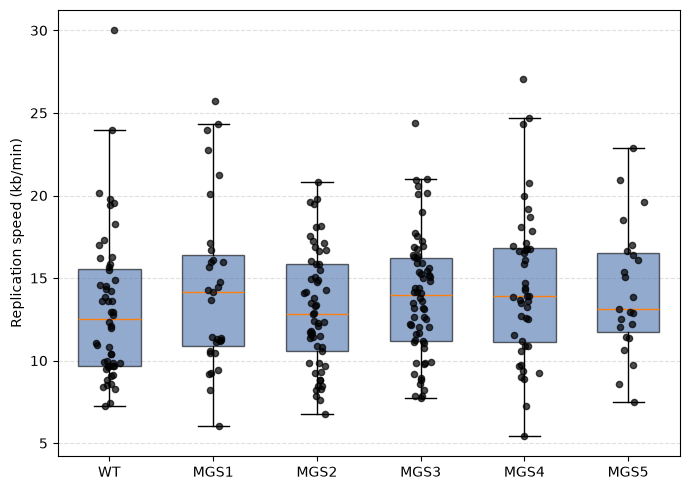

In [47]:
plt.figure(figsize=(7, 5))

# Variables
data_plot = replication_speed
var = "Speed_kb_min"

# Order of groups (optional)
sample_order = ["WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

groups = []
labels = []

for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)

    

bp = plt.boxplot(
    groups,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
for i, values in enumerate(groups, start=1):
    x = np.random.normal(i, 0.05, len(values))
    plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("Replication speed (kb/min)")
plt.xticks(range(1, len(labels) + 1), labels)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{input_dir}/replication_speed_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {input_dir}")

plt.show()

## IOD graph

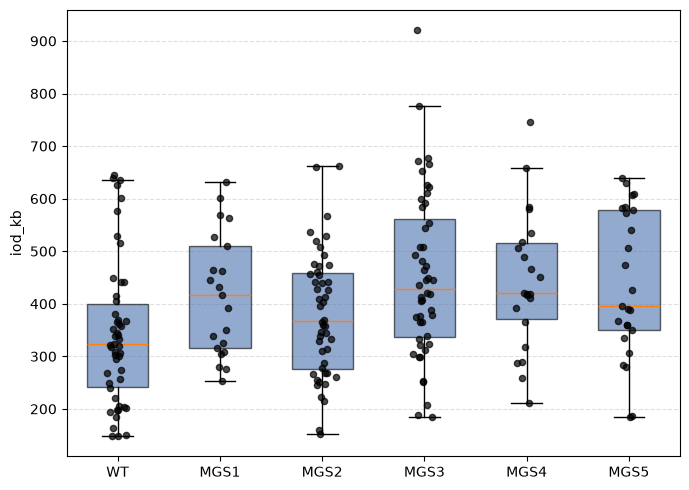

In [48]:
plt.figure(figsize=(7, 5))

# Variables
data_plot = iod_kb
var = "IOD_kb"

# Order of groups (optional)
sample_order = ["WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

groups = []
labels = []

for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)

    

bp = plt.boxplot(
    groups,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
for i, values in enumerate(groups, start=1):
    x = np.random.normal(i, 0.05, len(values))
    plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("iod_kb")
plt.xticks(range(1, len(labels) + 1), labels)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
#plt.savefig(f"{input_dir}/replication_speed_boxplot.png", dpi=600, bbox_inches="tight")
#print(f"Plot is saved in the directory: {input_dir}")

plt.show()

# Statistical analysis

## U-test

In [49]:
# Data
data_plot = iod_kb
var = "IOD_kb"

wt = data_plot.loc[
    data_plot["Sample_name"] == "WT",
    var
].dropna()

results = []

for sample in ["MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    mutant = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ].dropna()

    stat, p = mannwhitneyu(
        wt,
        mutant
    )

    results.append({
        "Comparison": f"WT vs {sample}",
        "WT_n": len(wt),
        "Sample_n": len(mutant),
        "U": stat,
        "p-value": p,
    })

stats_u_df = pd.DataFrame(results)

print(stats_u_df)

   Comparison  WT_n  Sample_n      U   p-value
0  WT vs MGS1    50        21  350.0  0.027914
1  WT vs MGS2    50        48  945.0  0.070505
2  WT vs MGS3    50        48  693.0  0.000319
3  WT vs MGS4    50        22  308.0  0.003155
4  WT vs MGS5    50        25  387.0  0.007602


## T-Test

In [50]:
# Data
data_plot = iod_kb
var = "IOD_kb"

wt = data_plot.loc[
    data_plot["Sample_name"] == "WT",
    var
].dropna()

results = []

for sample in ["MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    mutant = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ].dropna()

    stat, p = ttest_ind(
        wt,
        mutant,
        equal_var=False,   # Welch's t-test (recommended)
    )

    results.append({
        "Comparison": f"WT vs {sample}",
        "WT_n": len(wt),
        "Sample_n": len(mutant),
        "U": stat,
        "p-value": p,
    })

stats_t_df = pd.DataFrame(results)

print(stats_t_df)

   Comparison  WT_n  Sample_n         U   p-value
0  WT vs MGS1    50        21 -2.334616  0.024170
1  WT vs MGS2    50        48 -1.418710  0.159259
2  WT vs MGS3    50        48 -3.682950  0.000386
3  WT vs MGS4    50        22 -2.938005  0.005344
4  WT vs MGS5    50        25 -2.784056  0.007681


# Data export

In [ ]:

replication_speed.to_excel(f"{input_dir}/replication_speed.xlsx", index=False)
iod_kb.to_excel(f"{input_dir}/iod_kb.xlsx", index=False)